In [1]:
import pandas as pd 

df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df["Churn"].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

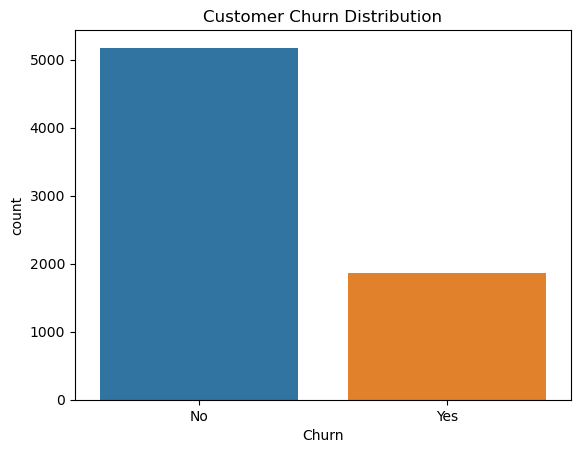

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn",data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [7]:
df["Churn"].value_counts(normalize=True)*100

No     73.463013
Yes    26.536987
Name: Churn, dtype: float64

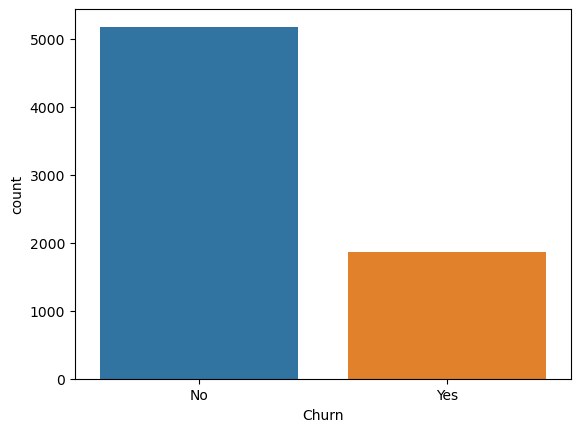

In [8]:
sns.countplot(x="Churn", data=df)
plt.show()

In [9]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [10]:
df["TotalCharges"].dtype


dtype('O')

In [11]:
pd.to_numeric(df["TotalCharges"],errors="coerce")

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [12]:
pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).isnull().sum()

11

In [13]:
df[pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [14]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")

In [15]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [16]:
df["TotalCharges"].dtype

dtype('float64')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [19]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


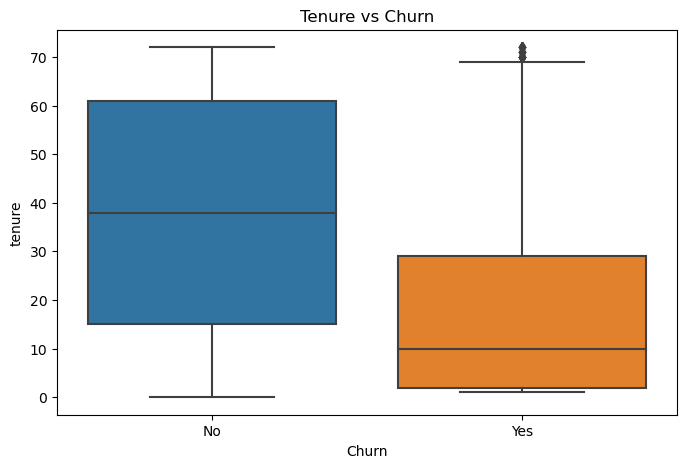

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")
plt.show()

In [21]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


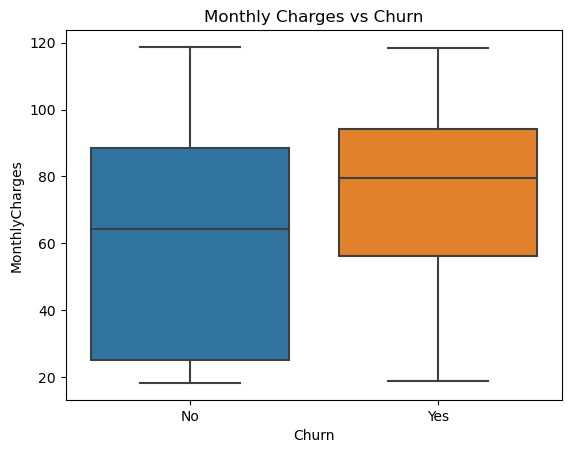

In [22]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

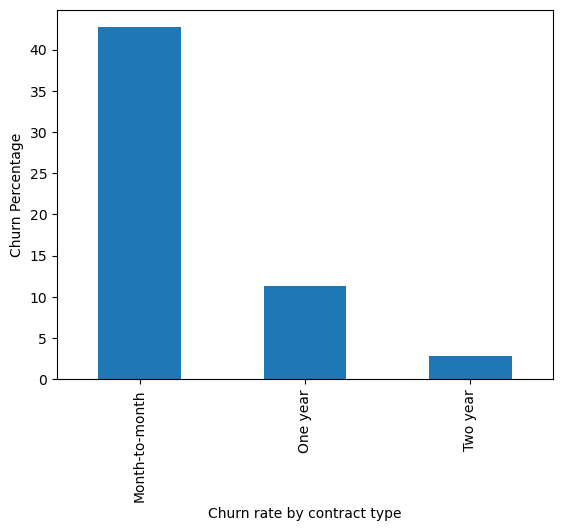

In [23]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],

    normalize="index"
)*100

contract_churn["Yes"].plot(
    kind="bar"
)

plt.ylabel("Churn Percentage")
plt.xlabel("Churn rate by contract type")
plt.show()

In [24]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


### Online Security Analysis

Hypothesis:
Customers with Online Security will churn less because they are more invested in the company's service ecosystem.

Result:
Confirmed.

Findings:
- Customers without Online Security had a churn rate of 41.77%.
- Customers with Online Security had a churn rate of 14.61%.

Business Insight:
Customers purchasing value-added services such as Online Security are significantly more likely to remain with the company.

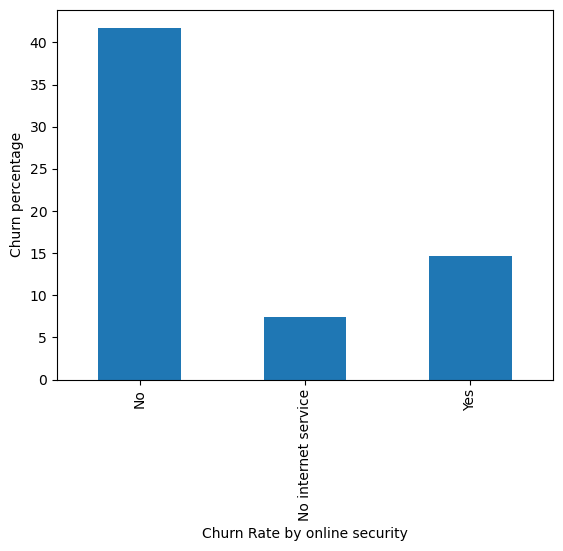

In [25]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
)*100

security_churn["Yes"].plot(kind="bar")
plt.ylabel("Churn percentage")
plt.xlabel("Churn Rate by online security")
plt.show()


In [26]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [27]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [28]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## Dependents Analysis

### Hypothesis

Customers with dependents are expected to have a lower churn rate because switching telecom providers affects multiple family members, increasing the inconvenience and switching cost.

### Business Reasoning

Families often prefer stability. A provider change may disrupt communication or internet services for several people, making them less likely to switch.

In [29]:
pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903


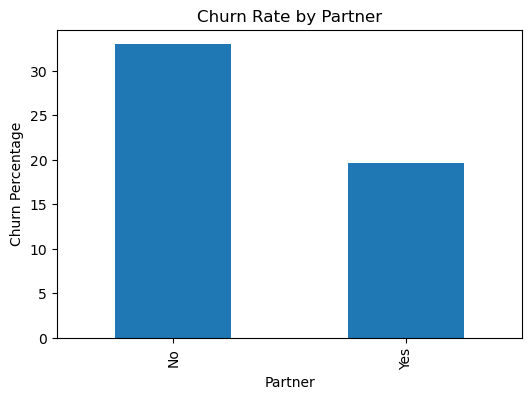

In [30]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

print(partner_churn)

partner_churn["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Partner")
plt.show()

Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637


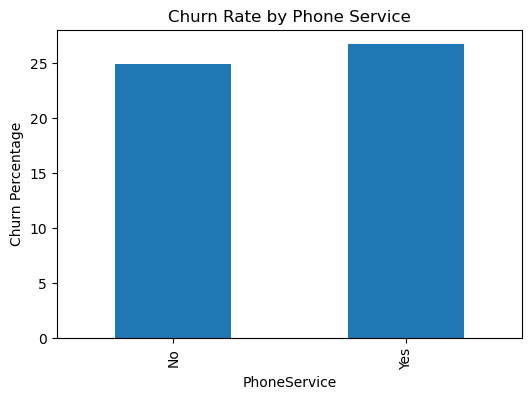

In [31]:
phone_churn = pd.crosstab(
    df["PhoneService"],
    df["Churn"],
    normalize="index"
) * 100

print(phone_churn)

phone_churn["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Phone Service")
plt.show()

Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896


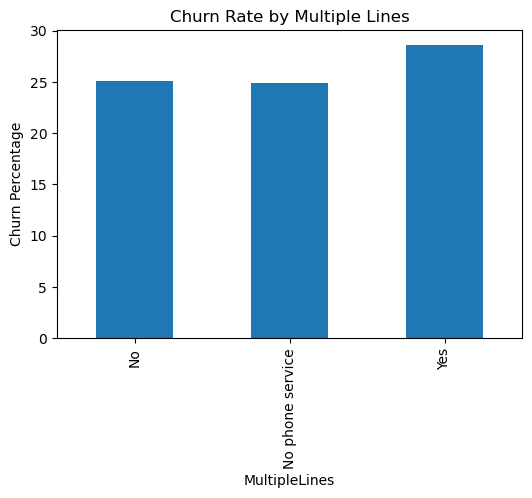

In [32]:
multiple_churn = pd.crosstab(
    df["MultipleLines"],
    df["Churn"],
    normalize="index"
) * 100

print(multiple_churn)

multiple_churn["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Multiple Lines")
plt.show()

Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494


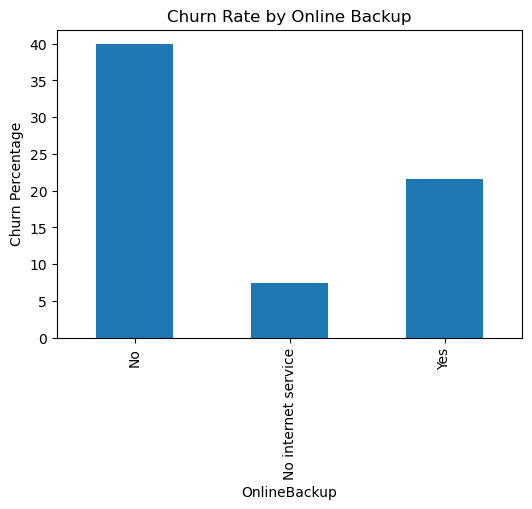

In [33]:
backup_churn = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

print(backup_churn)

backup_churn["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Online Backup")
plt.show()

Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064


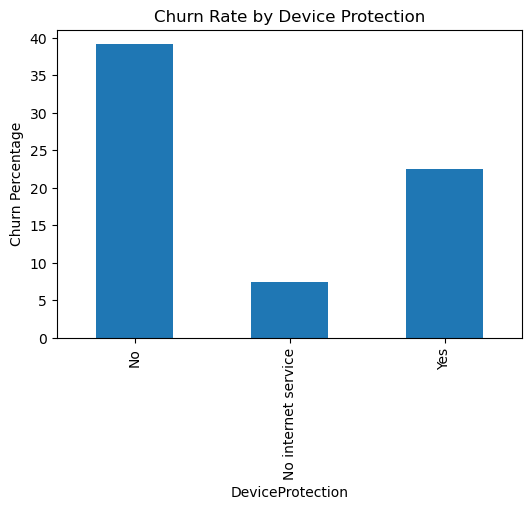

In [34]:
device_churn = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

print(device_churn)

device_churn["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Device Protection")
plt.show()

Churn                       No        Yes
StreamingTV                              
No                   66.476868  33.523132
No internet service  92.595020   7.404980
Yes                  69.929812  30.070188


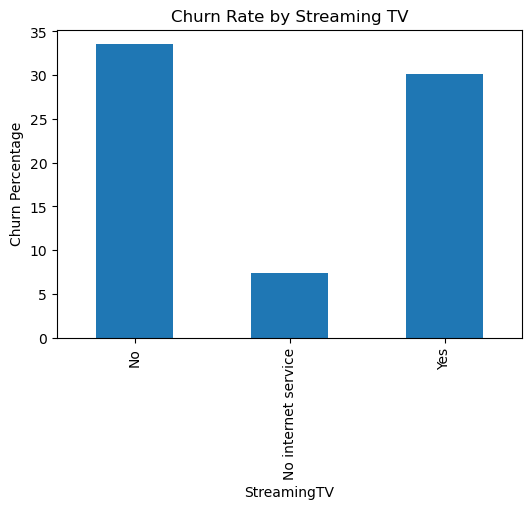

In [35]:
tv_churn = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

print(tv_churn)

tv_churn["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Streaming TV")
plt.show()

Churn                       No        Yes
StreamingMovies                          
No                   66.319569  33.680431
No internet service  92.595020   7.404980
Yes                  70.058565  29.941435


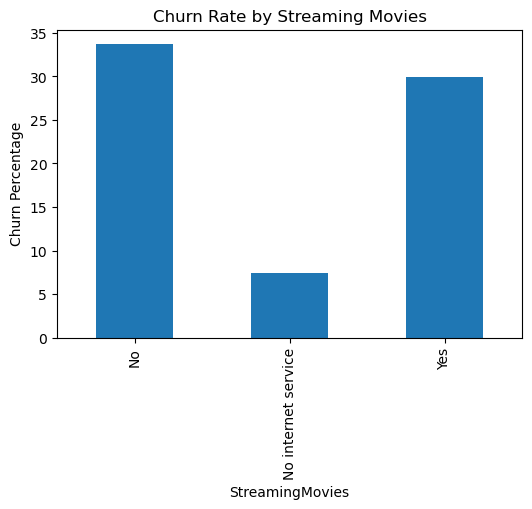

In [36]:
movie_churn = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

print(movie_churn)

movie_churn["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Streaming Movies")
plt.show()

Churn                    No        Yes
PaperlessBilling                      
No                83.669916  16.330084
Yes               66.434908  33.565092


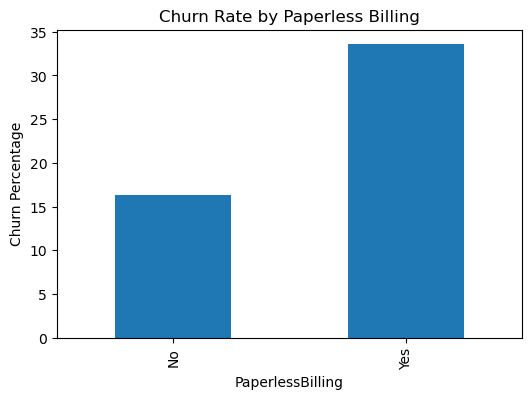

In [37]:
paper_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

print(paper_churn)

paper_churn["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Paperless Billing")
plt.show()

Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


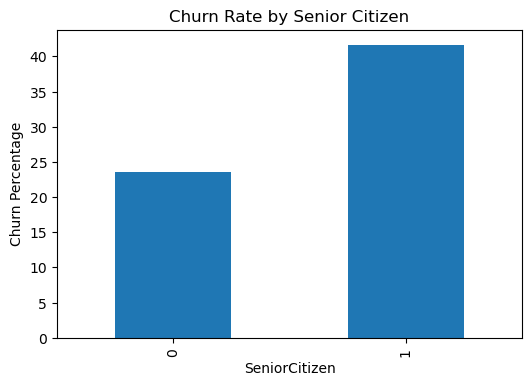

In [38]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print(senior_churn)

senior_churn["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Senior Citizen")
plt.show()

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


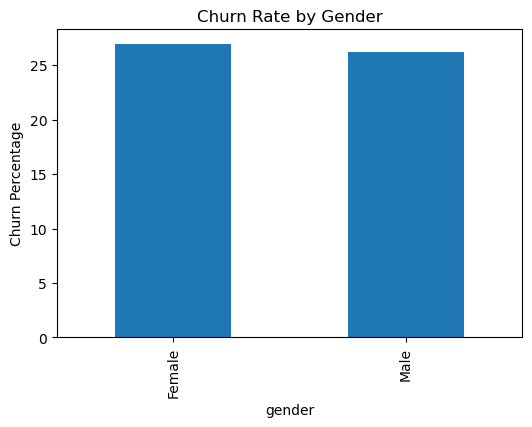

In [39]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print(gender_churn)

gender_churn["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Churn Percentage")
plt.title("Churn Rate by Gender")
plt.show()

# Key Findings from EDA

## Customer Behavior
- Customers with lower tenure are much more likely to churn.
- Customers paying higher monthly charges have a higher churn rate.
- Month-to-month contracts have the highest churn.
- Two-year contracts have the lowest churn.

## Services
- Customers without Online Security and Tech Support churn significantly more.
- Fiber Optic customers churn more than DSL customers.
- Customers using Electronic Check have the highest churn.
- Customers with Dependents and Partners are less likely to churn.
- Multiple additional services generally correlate with lower churn.

## Business Recommendations
- Encourage Month-to-month customers to migrate to yearly plans.
- Offer retention discounts for Fiber Optic customers.
- Bundle Online Security and Tech Support with internet plans.
- Target new customers during their first year with loyalty campaigns.